In [2]:
# from datetime import datetime
import polars as pl
import numpy as np
import matplotlib.pyplot as plt


pl.Config.set_tbl_rows(-1)
pl.Config.set_decimal_separator(',')
pl.Config.set_thousands_separator('.')
pl.Config.set_float_precision(2)

ENDERECO_DADOS = './../../DADOS/BOLSA_FAMILIA/'
ENDERECO_VOTACAO = './../../DADOS/VOTACAO/'
# ENDERECO_DADOS = 'C:/DADOS/NOVO_BOLSA_FAMILIA/'
# ENDERECO_VOTACAO = 'C:/DADOS/VOTACAO/'

###### Obtendo os dados e filtrando os registros 13 e 22

In [3]:

# Obtendo dados 
try:
    df_bolsa_familia = pl.scan_parquet(ENDERECO_DADOS + 'bolsa_familia.parquet')
    # print(df_bolsa_familia)

    df_dados_votacao = pl.read_csv(ENDERECO_VOTACAO + 'votacao_secao_2022_BR.csv', separator=';', encoding='iso-8859-1')
    print(df_dados_votacao.columns)

    # Filtrar p/ segundo turno 'NR_TURNO' e nº Votável 'NR_VOTAVEL' 13 e 22
    df_votacao_turno2 = df_dados_votacao.filter(
        (pl.col('NR_TURNO') == 2) & 
        (pl.col('NR_VOTAVEL').is_in([13, 22]))
    )

    print('Dados obtidos com sucesso')
except Exception as e:
    print(f'Erro ao obter dados: {e}')

['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'NR_TURNO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO', 'TP_ABRANGENCIA', 'SG_UF', 'SG_UE', 'NM_UE', 'CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'CD_CARGO', 'DS_CARGO', 'NR_VOTAVEL', 'NM_VOTAVEL', 'QT_VOTOS', 'NR_LOCAL_VOTACAO', 'SQ_CANDIDATO', 'NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO']
Dados obtidos com sucesso


In [4]:
# Processamento Votação
try:
    # Delimitar as variáveis, converter Categorical, Agrupar/totalizar
    print()

    # Delimitar as variáveis 'SG_UF', 'NM_VOTAVEL', 'QT_VOTOS'
    df_votacao = df_votacao_turno2.lazy().select(['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS'])
    # print(df_votacao)

    # Converter Categorical
    df_votacao = df_votacao.with_columns(
        pl.col('SG_UF').cast(pl.Categorical),
        pl.col('NM_VOTAVEL').cast(pl.Categorical)
    )

    # Agrupar/totalizar
    df_votacao = (
        df_votacao.group_by(['SG_UF', 'NM_VOTAVEL'])
        .agg(pl.col('QT_VOTOS')
        .sum())
        .sort('SG_UF', descending=False)
    )

    # coletar os dados
    # df_votacao = df_votacao.collect()
    # display(df_votacao)  # print do jupyter
    # print(df_votacao)

except Exception as e:
    print(f'Erro ao processar dados de votação: {e}')

In [5]:
# Processamento Bolsa Família
try:
    # Delimitar as variáveis, converter Categorical, Agrupar/totalizar

    # delimitando as vaiáveis 'UF', 'VALOR PARCELA'
    df_bolsa_familia = df_bolsa_familia.lazy().select(['UF', 'VALOR PARCELA'])

    # Converter Categorical
    df_bolsa_familia = df_bolsa_familia.with_columns(
        pl.col('UF').cast(pl.Categorical)
    )

    # Agrupar/totalizar
    df_bolsa_familia = (
        df_bolsa_familia.group_by('UF')
        .agg(pl.col('VALOR PARCELA').sum())
        .sort('UF', descending=False)
    )

    # coletar os dados
    # df_bolsa_familia = df_bolsa_familia.collect()
    # display(df_bolsa_familia)  # print do jupyter

except Exception as e:
    print(f'Erro ao processar dados de bolsa família: {e}')

In [6]:
# Realizando o Merge nos dados
try:
    # No polars => Join()  | No Pandas => merge()
    df_votos_bolsa_familia = (
        df_votacao.join(df_bolsa_familia, left_on='SG_UF', right_on='UF')
    )

    df_votos_bolsa_familia = df_votos_bolsa_familia.collect().sort('VALOR PARCELA', descending=True)
    display(df_votos_bolsa_familia)

except Exception as e:
    print(f'Erro ao realizar merge dos dados: {e}')

SG_UF,NM_VOTAVEL,QT_VOTOS,VALOR PARCELA
cat,cat,i64,f64
"""BA""","""JAIR MESSIAS BOLSONARO""",2.357.028,"7.775.720.895,00"
"""BA""","""LUIZ INÁCIO LULA DA SILVA""",6.097.815,"7.775.720.895,00"
"""SP""","""JAIR MESSIAS BOLSONARO""",14.216.587,"7.450.021.108,00"
"""SP""","""LUIZ INÁCIO LULA DA SILVA""",11.519.882,"7.450.021.108,00"
"""PE""","""LUIZ INÁCIO LULA DA SILVA""",3.640.933,"4.945.106.688,00"
"""PE""","""JAIR MESSIAS BOLSONARO""",1.798.832,"4.945.106.688,00"
"""MG""","""JAIR MESSIAS BOLSONARO""",6.141.310,"4.755.366.777,00"
"""MG""","""LUIZ INÁCIO LULA DA SILVA""",6.190.960,"4.755.366.777,00"
"""RJ""","""LUIZ INÁCIO LULA DA SILVA""",4.156.217,"4.740.470.130,00"


In [7]:
# Verificando a Correlação entre Votos e Bolsa Família
try:
    dict_correlacoes = {}  # guardar a correlação dos candidatos

    for candidato in df_votos_bolsa_familia['NM_VOTAVEL'].unique():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)

        # criar arrays numpy valor parcela e votos
        array_votos = np.array(df_candidato['QT_VOTOS'])
        array_bolsa_familia = np.array(df_candidato['VALOR PARCELA'])

        # calcular a correlação
        # O resultado é sempre um matriz, onde o elemento [0, 1] é a 
        # correlação entre os dois arrays. Primeira linha, na segunda coluna.
        correlacao = np.corrcoef(array_votos, array_bolsa_familia)[0, 1]

        print(f'Correlação do canditado {candidato}: {correlacao}')
        dict_correlacoes[candidato] = correlacao
    
    print('Correlacao Calculada')

except Exception as e:
    print(f'Erro ao calcular correlação: {e}')

Correlação do canditado LUIZ INÁCIO LULA DA SILVA: 0.8908468647835881
Correlação do canditado JAIR MESSIAS BOLSONARO: 0.6327548707321815
Correlacao Calculada


Plotando os gráficos...


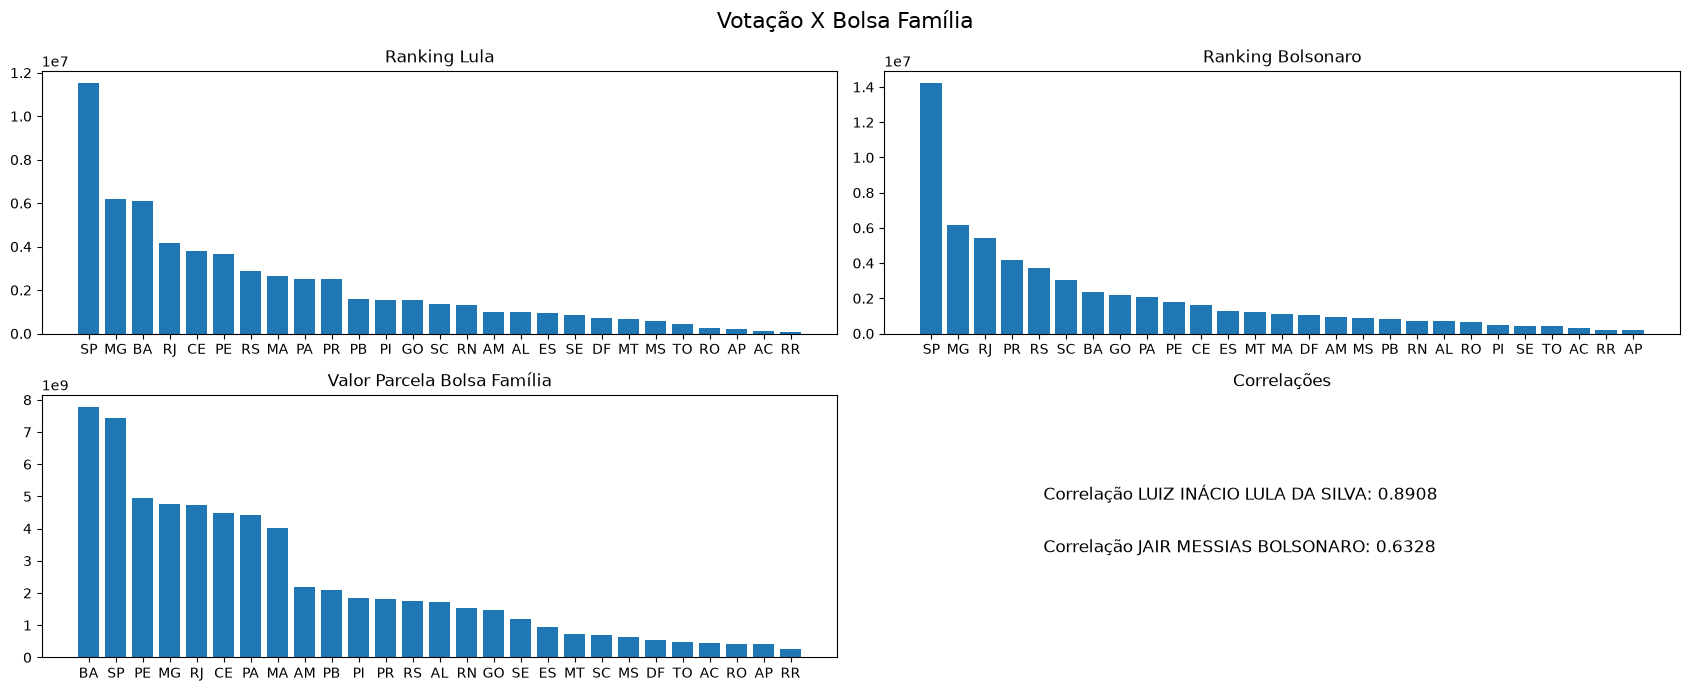

In [8]:
# Visualização dos dados
try:
    print('Plotando os gráficos...')

    plt.subplots(2, 2, figsize=(17, 7))
    plt.suptitle('Votação X Bolsa Família', fontsize=16)

    # Posição 1:  Ranking Lula
    plt.subplot(2, 2, 1)
    df_lula = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'LUIZ INÁCIO LULA DA SILVA')
    df_lula = df_lula.sort('QT_VOTOS', descending=True)

    # Gráfico de Colunas
    plt.bar(df_lula['SG_UF'], df_lula['QT_VOTOS'])
    plt.title('Ranking Lula')



    # Posição 2:  Ranking Bolsonaro
    plt.subplot(2, 2, 2)
    df_bolsonaro = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'JAIR MESSIAS BOLSONARO')
    df_bolsonaro = df_bolsonaro.sort('QT_VOTOS', descending=True)

    # Gráfico de Colunas
    plt.bar(df_bolsonaro['SG_UF'], df_bolsonaro['QT_VOTOS'])
    plt.title('Ranking Bolsonaro')



    # Posição 3:  Ranking Bolsa Família
    plt.subplot(2, 2, 3)
    plt.title('Valor Parcela Bolsa Família')

    # Gráfico de Colunas
    # df_bolsa_familia = df_bolsa_familia.collect()
    df_votos_bolsa_familia = df_votos_bolsa_familia.sort('VALOR PARCELA', descending=True)
    plt.bar(df_votos_bolsa_familia['SG_UF'], df_votos_bolsa_familia['VALOR PARCELA'])


    
    # Posição 4:  Correlação
    plt.subplot(2, 2, 4)
    plt.title('Correlações')

    x = 0.2
    y = 0.6

    for candidato, correlacao in dict_correlacoes.items():
        plt.text(x, y , f'Correlação {candidato}: {correlacao:.4f}', fontsize=12)

        y = y - 0.2
        
    plt.axis('off')
    plt.tight_layout()
    # plt.show()


except Exception as e:
    print(f'Erro ao visualizar dados: {e}')

Gerando gráficos de dispersão...


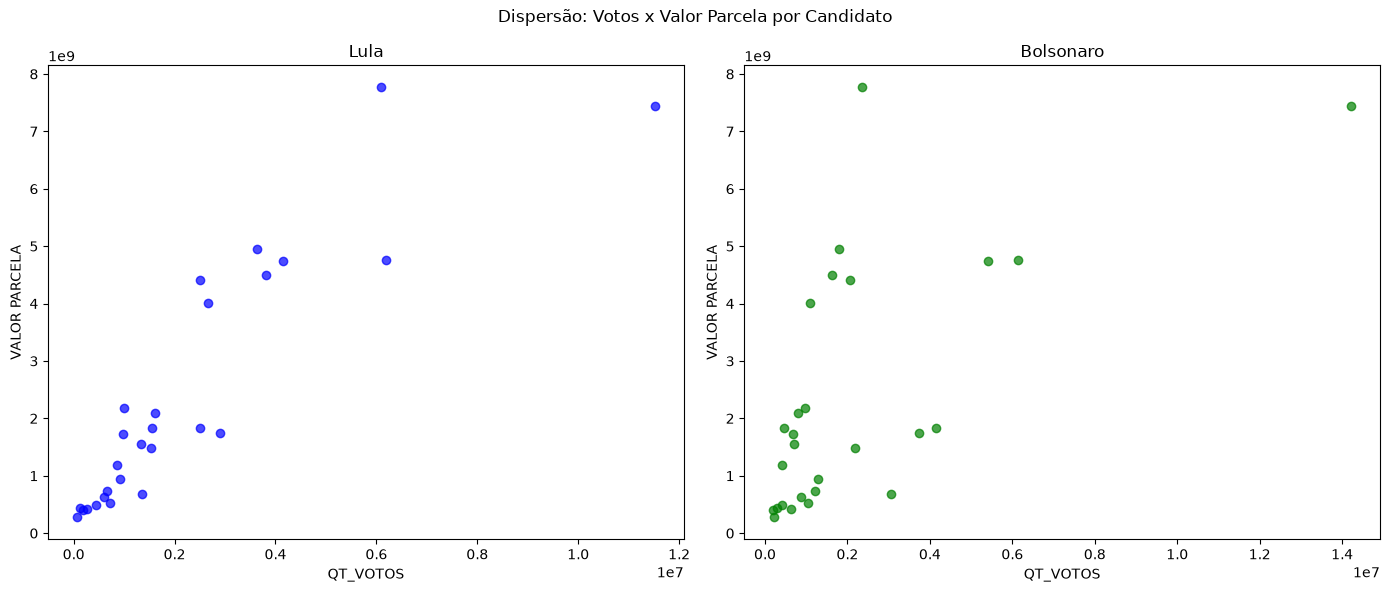

In [9]:
# Gráfico de Dispersão Lula e Bolsonaro
try:
    print('Gerando gráficos de dispersão...')

    plt.figure(figsize=(14, 6))
    plt.suptitle('Dispersão: Votos x Valor Parcela por Candidato')


    # Subplot para Lula
    plt.subplot(1, 2, 1)
    df_lula = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'LUIZ INÁCIO LULA DA SILVA')
    plt.scatter(df_lula['QT_VOTOS'], df_lula['VALOR PARCELA'], alpha=0.7, color='blue')
    plt.title('Lula')
    plt.xlabel('QT_VOTOS')
    plt.ylabel('VALOR PARCELA')


    # Subplot para Bolsonaro
    plt.subplot(1, 2, 2)
    df_bolsonaro = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'JAIR MESSIAS BOLSONARO')
    plt.scatter(df_bolsonaro['QT_VOTOS'], df_bolsonaro['VALOR PARCELA'], alpha=0.7, color='green')
    plt.title('Bolsonaro')
    plt.xlabel('QT_VOTOS')
    plt.ylabel('VALOR PARCELA')

    plt.tight_layout()
    # plt.show()
    
except Exception as e:
    print(f'Erro ao gerar gráficos de dispersão: {e}')